<a href="https://colab.research.google.com/github/nilsberzins/stat-405-final/blob/main/EDA405.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Connect to Database and pull data

In [123]:
!pip install pymysql --quiet
!pip install boto3 --quiet
!pip install sqlalchemy --quiet
!pip install python-dotenv --quiet
!pip install prophet --quiet
!pip install xgboost --quiet

In [124]:
# package for env variables in google colab: https://pypi.org/project/colab-env/
!pip install colab-env -qU
import colab_env

In [125]:
from colab_env import envvar_handler # modify env variables in var.env file in google drive

In [126]:
import pymysql
import sys
import boto3
import os
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
import xgboost as xgb
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import scipy.stats as stats

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import RidgeCV
from statsmodels.stats.anova import anova_lm
from statsmodels.formula.api import ols
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [127]:
connection = pymysql.connect(
    host=os.getenv("AWS_DATABASE_ENDPOINT"),
    user=os.getenv("AWS_USER"),
    port=int(os.getenv("AWS_PORT")),
    passwd=os.getenv("AWS_PASSWORD"),
    database=os.getenv("AWS_DBNAME")
)

In [128]:
with connection.cursor() as cursor:
    cursor.execute("SHOW TABLES")
    tables = cursor.fetchall()

# Print table names
for table in tables:
    print(table[0])

CA_funding_dataset
CSU_Data_2010
CSU_Data_2011
CSU_Data_2012
CSU_Data_2013
CSU_Data_2014
CSU_Data_2015
CSU_Data_2016
CSU_Data_2017
CSU_salaries_data
Inflation_data
SuperBowl_coinTosses
UCOP_Data_2010
UCOP_Data_2011
UCOP_Data_2012
UCOP_Data_2013
UCOP_Data_2014
UCOP_Data_2015
UCOP_Data_2016
UCOP_Data_2017
UCOP_Data_2018
UCOP_Data_2019
UCOP_Data_2020
UCOP_Data_2021
UCOP_Data_2022
UCOP_Data_2023
google_elev_68sites
iris_data
nhl_goalieDate
nhl_playerDate
nhl_teamDate


**Load Data from AWS**

In [129]:
funding_df = pd.read_sql("SELECT * FROM CA_funding_dataset", con=connection)
funding_df = funding_df[["FY", "% Tax Appropriations", "% Local", "% General Operating", "% RAM", "% Public Financial Aid", "Education Appropriations Per FTE ($)",
                         "Public Financial Aid Per FTE ($)", "Public Financial Aid as a % of Education Appropriations",
                         "Net Tuition Revenue Per FTE ($)", "Student Share (%)", "Total Education Revenue Per FTE ($)"
                         ]]

funding_df.head()

<ipython-input-129-2819538397>:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  funding_df = pd.read_sql("SELECT * FROM CA_funding_dataset", con=connection)


,FY,% Tax Appropriations,% Local,% General Operating,% RAM,% Public Financial Aid,Education Appropriations Per FTE ($),Public Financial Aid Per FTE ($),Public Financial Aid as a % of Education Appropriations,Net Tuition Revenue Per FTE ($),Student Share (%),Total Education Revenue Per FTE ($)
0,2024.0,80.9,16.9,85.0,5.1,9.0,15006.0,1430.0,9.5,3631.0,19.5,"$18,637"
1,2023.0,80.7,16.7,84.2,6.2,8.7,15601.0,1463.0,9.4,3939.0,20.2,"$19,541"
2,2022.0,82.1,15.4,85.0,5.5,8.5,16497.0,1488.0,9.0,4114.0,20.0,"$20,612"
3,2021.0,80.7,17.0,84.5,4.0,10.4,14235.0,1555.0,10.9,4115.0,22.4,"$18,350"
4,2020.0,80.9,17.0,85.7,5.3,8.2,13080.0,1145.0,8.7,4582.0,25.9,"$17,662"


In [130]:
inflation_df = pd.read_sql("SELECT * FROM Inflation_data", con=connection)
inflation_df.head()

<ipython-input-130-3206808615>:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  inflation_df = pd.read_sql("SELECT * FROM Inflation_data", con=connection)


,row_names,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,HALF1,HALF2
0,1,2000.0,168.8,169.8,171.2,171.3,171.5,172.4,172.8,172.8,173.7,174.0,174.1,174.0,170.8,173.6
1,2,2001.0,175.1,175.8,176.2,176.9,177.7,178.0,177.5,177.5,178.3,177.7,177.4,176.7,176.6,177.5
2,3,2002.0,177.1,177.8,178.8,179.8,179.8,179.9,180.1,180.7,181.0,181.3,181.3,180.9,178.9,180.9
3,4,2003.0,181.7,183.1,184.2,183.8,183.5,183.7,183.9,184.6,185.2,185.0,184.5,184.3,183.3,184.6
4,5,2004.0,185.2,186.2,187.4,188.0,189.1,189.7,189.4,189.5,189.9,190.9,191.0,190.3,187.6,190.2


In [131]:
# add a column which is the annual average CPI
inflation_df['delta_cpi'] = inflation_df["Dec"].pct_change() * 100
inflation_df["Year"] = inflation_df["Year"].astype(int)
inflation_df = inflation_df[inflation_df["Year"] >= 2010]
inflation_filt = inflation_df[["Year", "Dec", "delta_cpi"]][:-2]
inflation_filt.head()

<ipython-input-131-3270998329>:2: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  inflation_df['delta_cpi'] = inflation_df["Dec"].pct_change() * 100


,Year,Dec,delta_cpi
10,2010,219.179,1.495724
11,2011,225.672,2.962419
12,2012,229.601,1.741022
13,2013,233.049,1.501736
14,2014,234.812,0.756493


In [132]:
#reading in UC data
years = range(2010, 2024)
dfs = []

for year in years:
    query = f"""
    SELECT '{year}' AS year, location, title, `regular.pay`
    FROM `UCOP_Data_{year}`
    """
    df = pd.read_sql(query, con=connection)

    if year in [2013, 2014, 2015]:
        df = df.applymap(lambda x: x.strip("'") if isinstance(x, str) else x)

    df["year"] = df["year"].astype(int)
    df["regular.pay"] = pd.to_numeric(df["regular.pay"], errors='coerce')

    dfs.append(df)

full_data = pd.concat(dfs, ignore_index=True)
full_data.head()

<ipython-input-132-563893949>:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, con=connection)
<ipython-input-132-563893949>:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, con=connection)
<ipython-input-132-563893949>:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, con=connection)
<ipython-input-132-563893949>:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBA

,year,location,title,regular.pay
0,2010,Santa Cruz,ASSISTANT PROFESSOR-ACAD YR,69999.96
1,2010,Berkeley,GRAD STDNT RES-FULL FEE REM,5369.42
2,2010,Berkeley,TEACHING ASSISTANT - GSHIP,4802.00
3,2010,Berkeley,GRAD STDNT RES- NO REMISSION,3409.01
4,2010,Berkeley,GRAD STDNT RES-FULL FEE REM,11673.90


**Data Cleaning/EDA**

In [133]:
#remove NA values
full_data = full_data.dropna()

In [135]:
#calculating and removing outliers for regular pay, removing 20000 since this was an average value for lower paying campuses
#original lower outlier based on IQR did not make sense since it was a negative value
full_data = full_data[full_data['regular.pay'] >= 20000]

In [136]:
full_data["location"].unique()

array(['Santa Cruz', 'Berkeley', 'DANR', 'Davis', 'Irvine', 'Los Angeles',
       'Merced', 'Riverside', 'San Diego', 'San Francisco',
       'Santa Barbara', 'UCOP', 'ASUCLA', 'Hastings College Of Law',
       'Hastings'], dtype=object)

In [137]:
#dropping more specialized UCs to not affect distribution
to_drop = ["San Francisco", "UCOP", "DANR", "Hastings", "Hastings College Of Law", "ASUCLA"]
full_data = full_data[~full_data["location"].isin(to_drop)]

In [138]:
#filtering out so it is only faculty
pattern = r"""(?ix)                     # (?i)=ignore-case  (?x)=verbose mode
    \b(?:                               # word-start, then one of…
        prof(?:essors?\b|\.?\b)         #  "professor" / "professors" / "prof" / "prof."
      | lect(?:urer?s?\b|\b)            #  "lecturer(s)" / "lect"
    )
"""

filtered = full_data[full_data['title'].str.contains(pattern, regex=True, na=False)]


In [139]:
#removing any summer term faculty, only want the full academic term
filtered = filtered[~(filtered["title"].str.contains("SUMMER"))]

In [140]:
filtered.head()

,year,location,title,regular.pay
0,2010,Santa Cruz,ASSISTANT PROFESSOR-ACAD YR,69999.96
20,2010,Berkeley,LECTURER - ACADEMIC YEAR,25454.75
94,2010,Berkeley,LECTURER - ACADEMIC YEAR,29248.46
175,2010,Berkeley,LECTURER - ACADEMIC YEAR,27058.69
178,2010,Berkeley,LECTURER - ACADEMIC YEAR,28679.78


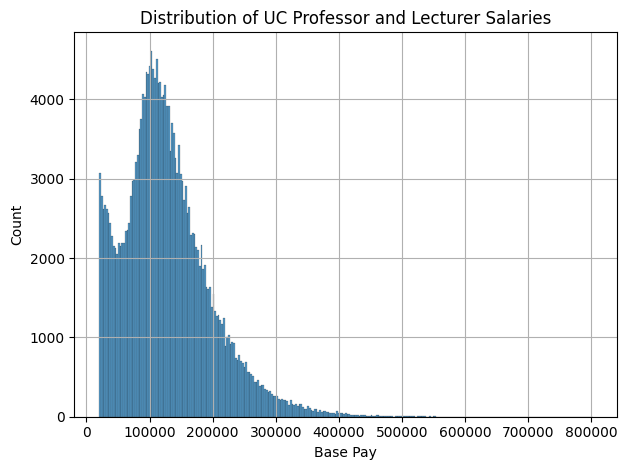

In [141]:
sns.histplot(filtered, x='regular.pay')
plt.title('Distribution of UC Professor and Lecturer Salaries')
plt.xlabel('Base Pay')
plt.tight_layout()
plt.grid(True)
plt.show()

In [142]:
#further condensing title into more categorized groups
def title_assign(x):
    if "PROFL" in x or "PROFESSIONAL" in x:
        return "OTHER"
    elif ("VST" in x or "VIS" in x) and "ASST" in x:
        return "VST ASST"
    elif ("VST" in x or "VIS" in x) and "ASSOC" in x:
        return "VST ASSOC"
    elif ("VST" in x or "VIS" in x):
        return "VST PROF"
    elif "ADJ" in x and "ASST" in x:
        return "ADJ ASST"
    elif ("ASOC" in x or "ASSOC" in x) and "ADJ" in x:
        return "ADJ ASOC"
    elif "ADJ" in x:
        return "ADJ PROF"
    elif ("ASST" in x or "ASSIST" in x) and "PROF" in x:
        return "ASST PROF"
    elif "ASSOC" in x and "PROF" in x:
        return "ASSOC PROF"
    elif "PROF" in x:
        return "PROF"
    elif "SR" in x and "LECT" in x:
        return "SR LECT"
    elif "LECT" in x:
        return "LECT"
    else:
        return "OTHER"

In [143]:
filtered['prof_rank'] = (
    filtered['title']
        .str.upper()
        .fillna('')
        .apply(title_assign)
)

filtered['year'] = filtered['year'].astype(int)


filtered.head()


,year,location,title,regular.pay,prof_rank
0,2010,Santa Cruz,ASSISTANT PROFESSOR-ACAD YR,69999.96,ASST PROF
20,2010,Berkeley,LECTURER - ACADEMIC YEAR,25454.75,LECT
94,2010,Berkeley,LECTURER - ACADEMIC YEAR,29248.46,LECT
175,2010,Berkeley,LECTURER - ACADEMIC YEAR,27058.69,LECT
178,2010,Berkeley,LECTURER - ACADEMIC YEAR,28679.78,LECT


In [144]:
filtered["prof_rank"].value_counts()

,count
prof_rank,
PROF,96964
ASST PROF,41891
ASSOC PROF,38795
LECT,33665
ADJ ASST,4360
ADJ PROF,3448
ADJ ASOC,2411
VST ASST,2355
SR LECT,2152


In [145]:
avg_salary = (
    filtered
      .groupby(['prof_rank', 'location'], as_index=False)
      .agg(avg_regular_pay=('regular.pay', 'mean'))
)

avg_salary


,prof_rank,location,avg_regular_pay
0,ADJ ASOC,Berkeley,93008.600269
1,ADJ ASOC,Davis,87246.502419
2,ADJ ASOC,Irvine,84090.719316
3,ADJ ASOC,Los Angeles,93056.404498
4,ADJ ASOC,Riverside,83422.896552
...,...,...,...
91,VST PROF,Merced,47664.833333
92,VST PROF,Riverside,37179.400000
93,VST PROF,San Diego,45322.150935
94,VST PROF,Santa Barbara,39249.503333


In [146]:
# some EDAs for filtered, existing features
# year: 2010-2023, some imbalance in representation for each year but not too bad
filtered['year'].value_counts()

,count
year,
2023,19666
2022,19332
2021,18925
2018,17679
2019,17571
2017,17144
2016,16604
2015,15724
2014,15267


In [147]:
# locations: LA, SD, Davis, Berkeley, Irvine, SB, Riverside, SC, Merced
# some imbalance in counts especially Merced is lower than the rest
filtered['location'].value_counts()

,count
location,
Los Angeles,54981
San Diego,37850
Davis,35592
Irvine,27857
Berkeley,27625
Santa Barbara,15200
Riverside,13093
Santa Cruz,10252
Merced,5133


**Aggregating Data Set and Adding Features**

In [148]:
cpi_df = inflation_filt[['Year', 'delta_cpi']]
cpi_df.columns = ['year', 'delta_cpi']
cpi_df.head()

,year,delta_cpi
10,2010,1.495724
11,2011,2.962419
12,2012,1.741022
13,2013,1.501736
14,2014,0.756493


<Axes: xlabel='year', ylabel='delta_cpi'>

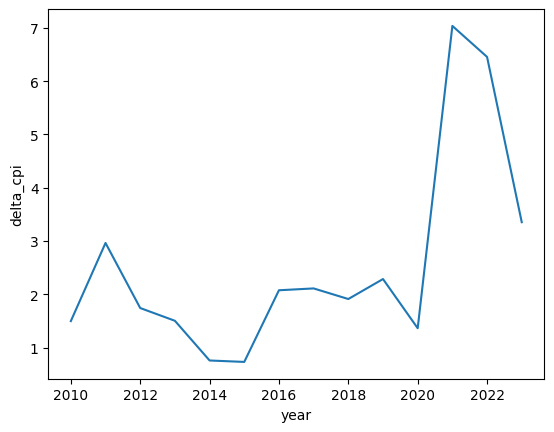

In [149]:
sns.lineplot(data=cpi_df, x='year', y='delta_cpi')
# INTERPRETATION TODO

In [150]:
#aggregating filtered dataset
uc_agg = filtered.drop(columns=['prof_rank', 'title'])

# Step 2: Group by year and location, then calculate average salary
uc_agg = (
    uc_agg
    .groupby(['location', 'year'])['regular.pay']
    .mean()
    .reset_index()
    .rename(columns={'regular.pay': 'avg_reg_pay'})
)

uc_agg.head()

,location,year,avg_reg_pay
0,Berkeley,2010,105596.643773
1,Berkeley,2011,105248.845794
2,Berkeley,2012,110032.315734
3,Berkeley,2013,112827.414955
4,Berkeley,2014,115688.831282


In [151]:
# add one feature - delta cpi for every year
uc_agg = uc_agg.merge(cpi_df, on='year')
uc_agg

,location,year,avg_reg_pay,delta_cpi
0,Berkeley,2010,105596.643773,1.495724
1,Berkeley,2011,105248.845794,2.962419
2,Berkeley,2012,110032.315734,1.741022
3,Berkeley,2013,112827.414955,1.501736
4,Berkeley,2014,115688.831282,0.756493
...,...,...,...,...
121,Santa Cruz,2019,109479.322767,2.285130
122,Santa Cruz,2020,120834.609544,1.362005
123,Santa Cruz,2021,116867.545888,7.036403
124,Santa Cruz,2022,121412.070684,6.454401


In [152]:
#adding enrollment data
enroll_df = pd.read_csv('/content/drive/MyDrive/Enrollment_levels.csv')
enroll_df.columns.values[0:2] = ['level', 'location']

enroll_long = enroll_df.melt(id_vars=['level', 'location'],
                             var_name='year',
                             value_name='student_enrollment')
enroll_long = enroll_long.dropna()

enroll_long['student_enrollment'] = enroll_long['student_enrollment'].str.replace(',', '')
enroll_long['student_enrollment'] = enroll_long['student_enrollment'].astype(int)
enroll_long['year'] = enroll_long['year'].astype(int)
enroll_long['location'] = enroll_long['location'].str.strip()

enroll_summary = enroll_long.groupby(['location', 'year'], as_index=False)['student_enrollment'].sum()
enroll_summary.head()



,location,year,student_enrollment
0,Berkeley,2010,35833
1,Berkeley,2011,36137
2,Berkeley,2012,35893
3,Berkeley,2013,36198
4,Berkeley,2014,37565


In [153]:
# add another feature - enrollment number unique to the combo of year & location
uc_agg = uc_agg.merge(enroll_summary, on=['year', 'location'])
uc_agg

,location,year,avg_reg_pay,delta_cpi,student_enrollment
0,Berkeley,2010,105596.643773,1.495724,35833
1,Berkeley,2011,105248.845794,2.962419,36137
2,Berkeley,2012,110032.315734,1.741022,35893
3,Berkeley,2013,112827.414955,1.501736,36198
4,Berkeley,2014,115688.831282,0.756493,37565
...,...,...,...,...,...
121,Santa Cruz,2019,109479.322767,2.285130,19494
122,Santa Cruz,2020,120834.609544,1.362005,19161
123,Santa Cruz,2021,116867.545888,7.036403,19841
124,Santa Cruz,2022,121412.070684,6.454401,19478


In [154]:
#adding funding data, so this is the finalized aggregated dataset
uc_agg = uc_agg.merge(funding_df, left_on='year', right_on='FY')
uc_agg = uc_agg.drop(columns=['FY'])

uc_agg.head()

,location,year,avg_reg_pay,delta_cpi,student_enrollment,% Tax Appropriations,% Local,% General Operating,% RAM,% Public Financial Aid,Education Appropriations Per FTE ($),Public Financial Aid Per FTE ($),Public Financial Aid as a % of Education Appropriations,Net Tuition Revenue Per FTE ($),Student Share (%),Total Education Revenue Per FTE ($)
0,Berkeley,2010,105596.643773,1.495724,35833,81.0,16.6,82.2,6.7,8.9,10436.0,937.0,9.0,2664.0,20.3,"$13,100"
1,Berkeley,2011,105248.845794,2.962419,36137,82.0,15.2,80.3,6.9,10.3,10526.0,1172.0,11.1,2489.0,19.1,"$13,015"
2,Berkeley,2012,110032.315734,1.741022,35893,79.1,17.5,76.6,6.0,14.7,9327.0,1499.0,16.1,3528.0,27.4,"$12,854"
3,Berkeley,2013,112827.414955,1.501736,36198,77.6,19.4,82.6,5.6,10.9,9711.0,1133.0,11.7,4185.0,30.1,"$13,897"
4,Berkeley,2014,115688.831282,0.756493,37565,80.2,16.9,81.3,4.7,12.7,10387.0,1403.0,13.5,3917.0,27.4,"$14,304"


In [155]:
#turning last col int
uc_agg['Total Education Revenue Per FTE ($)'] = (
    uc_agg['Total Education Revenue Per FTE ($)']
    .replace('[\$,]', '', regex=True)
    .astype(int))

uc_agg.head()

,location,year,avg_reg_pay,delta_cpi,student_enrollment,% Tax Appropriations,% Local,% General Operating,% RAM,% Public Financial Aid,Education Appropriations Per FTE ($),Public Financial Aid Per FTE ($),Public Financial Aid as a % of Education Appropriations,Net Tuition Revenue Per FTE ($),Student Share (%),Total Education Revenue Per FTE ($)
0,Berkeley,2010,105596.643773,1.495724,35833,81.0,16.6,82.2,6.7,8.9,10436.0,937.0,9.0,2664.0,20.3,13100
1,Berkeley,2011,105248.845794,2.962419,36137,82.0,15.2,80.3,6.9,10.3,10526.0,1172.0,11.1,2489.0,19.1,13015
2,Berkeley,2012,110032.315734,1.741022,35893,79.1,17.5,76.6,6.0,14.7,9327.0,1499.0,16.1,3528.0,27.4,12854
3,Berkeley,2013,112827.414955,1.501736,36198,77.6,19.4,82.6,5.6,10.9,9711.0,1133.0,11.7,4185.0,30.1,13897
4,Berkeley,2014,115688.831282,0.756493,37565,80.2,16.9,81.3,4.7,12.7,10387.0,1403.0,13.5,3917.0,27.4,14304


**Some Plots from full data set**

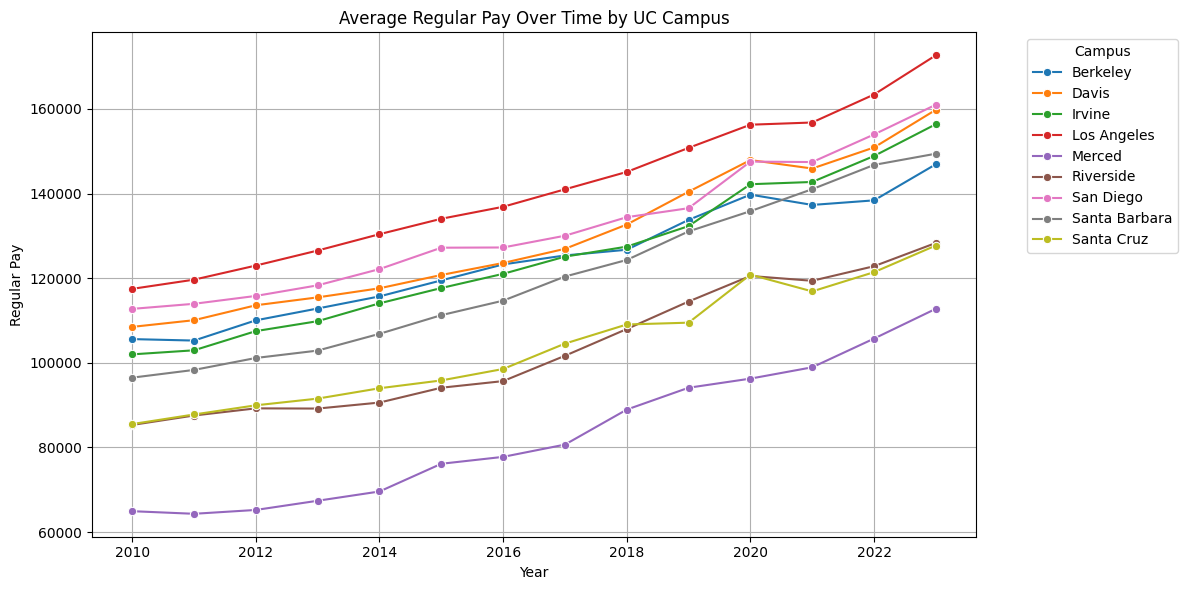

In [156]:
#time trend analysis plot by campus
avg_by_campus = filtered.groupby(['year', 'location'])['regular.pay'].mean().reset_index()

# Plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=avg_by_campus, x='year', y='regular.pay', hue='location', marker="o")

plt.title("Average Regular Pay Over Time by UC Campus")
plt.ylabel("Regular Pay")
plt.xlabel("Year")
plt.legend(title='Campus', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(True)
plt.show()

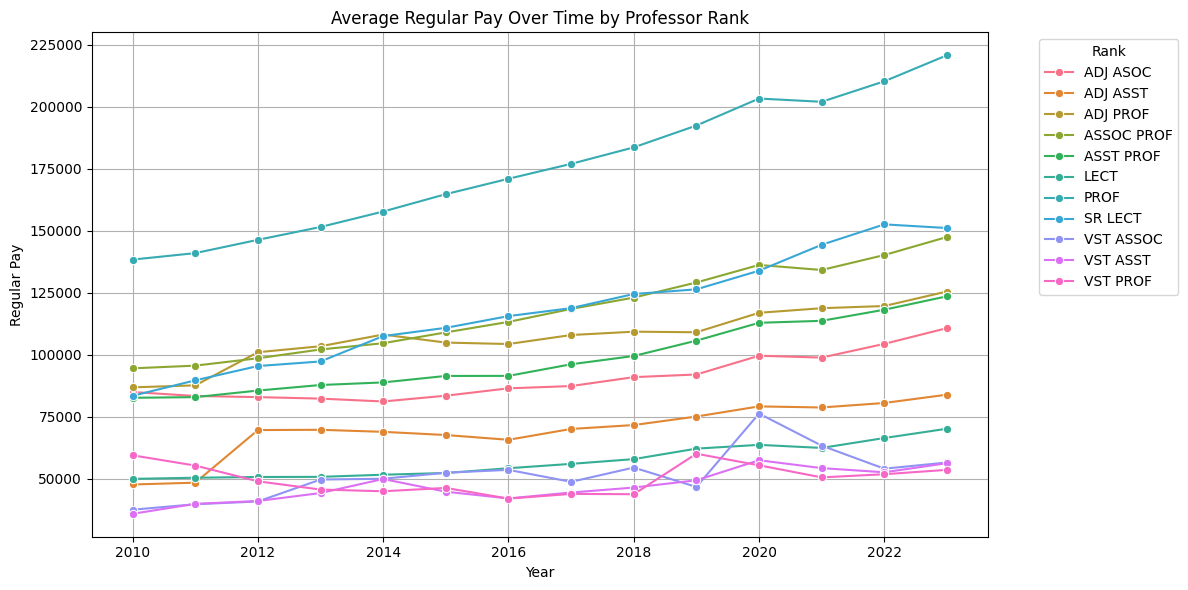

In [157]:
# By Rank
avg_rank = filtered.groupby(['year', 'prof_rank'])['regular.pay'].mean().reset_index()
plt.figure(figsize=(12, 6))
sns.lineplot(data=avg_rank , x='year', y='regular.pay', hue='prof_rank', marker="o")

plt.title("Average Regular Pay Over Time by Professor Rank")
plt.ylabel("Regular Pay")
plt.xlabel("Year")
plt.legend(title='Rank', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(True)
plt.show()

In [158]:
#want to see if there are disparities
summary = filtered.groupby(['year', 'prof_rank'])['regular.pay'].agg(['count', 'mean', 'median']).reset_index()
summary.head()


,year,prof_rank,count,mean,median
0,2010,ADJ ASOC,163,85051.071043,89800.08
1,2010,ADJ ASST,111,47764.390000,42500.29
2,2010,ADJ PROF,402,86934.605796,82799.97
3,2010,ASSOC PROF,2487,94598.500056,89100.00
4,2010,ASST PROF,2444,82716.868854,80300.28


***Statistical Analysis***

MODELING

**Updated Modeling**

*Random Forest*

R² score: 0.9491034983157914
RMSE: 5653.95114773795


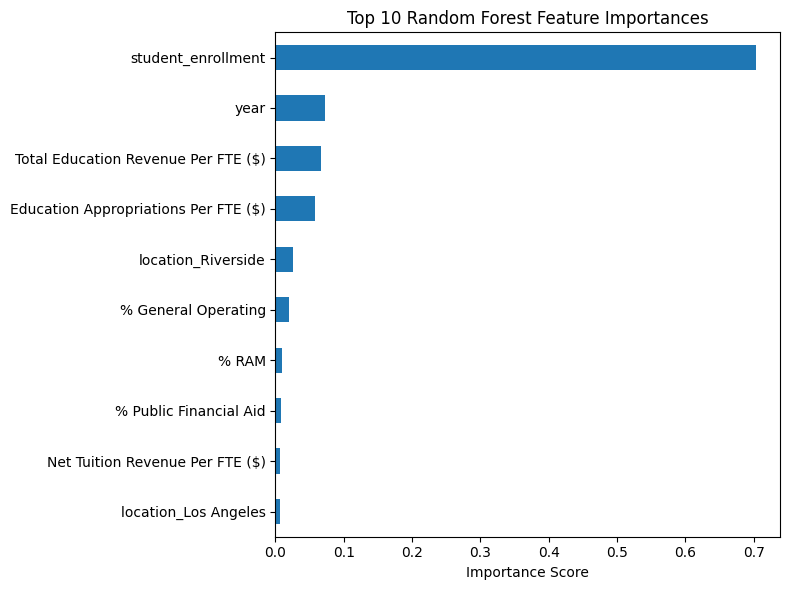

In [159]:
#random forest
# 1. Define predictors (all except 'avg_reg_pay')
X = uc_agg.drop(columns=['avg_reg_pay'])

# 2. One-hot encode the categorical predictor: 'location'
X = pd.get_dummies(X, columns=['location'], drop_first=True)

# 3. Define target
y = uc_agg['avg_reg_pay']

# 4. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5. Train Random Forest
rf = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
rf.fit(X_train, y_train)

# 6. Predict and evaluate
y_pred = rf.predict(X_test)
print("R² score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))


# 7. Feature importance plot
importances = pd.Series(rf.feature_importances_, index=X.columns)
top_10 = importances.sort_values(ascending=False).head(10)
top_10.sort_values().plot(kind='barh', figsize=(8, 6))
plt.title("Top 10 Random Forest Feature Importances")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()


In [160]:
#cross validation for random forest
X = uc_agg.drop(columns=['avg_reg_pay'])

X = pd.get_dummies(X, columns=['location'], drop_first=True)

y = uc_agg['avg_reg_pay']

#Define RMSE scorer manually
def rmse_cv(model, X, y, cv):
    rmse_scores = []
    for train_idx, test_idx in cv.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        rmse = np.sqrt(np.mean((y_test - y_pred)**2))
        rmse_scores.append(rmse)
    return rmse_scores

#Set up model and CV
rf = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
cv = KFold(n_splits=10, shuffle=True, random_state=42)

# R² with cross_val_score
r2_scores = cross_val_score(rf, X, y, cv=cv, scoring='r2')

# RMSE manually
rmse_scores = rmse_cv(rf, X, y, cv)

print("Cross-validated R² scores:", r2_scores)
print("Mean R²:", np.mean(r2_scores))
print("Standard Deviation R²:", np.std(r2_scores))

print("\nCross-validated RMSE scores:", rmse_scores)
print("Mean RMSE:", np.mean(rmse_scores))
print("Standard Deviation RMSE:", np.std(rmse_scores))

Cross-validated R² scores: [0.9552615  0.92839589 0.84850713 0.93233481 0.8335076  0.89840869
 0.89478575 0.95730144 0.91010803 0.92187673]
Mean R²: 0.908048756145158
Standard Deviation R²: 0.039018674413936166

Cross-validated RMSE scores: [np.float64(4146.492843940902), np.float64(7534.271891919978), np.float64(6448.564005769237), np.float64(5749.05690542674), np.float64(5184.491891817279), np.float64(5934.41147959654), np.float64(7795.708800592064), np.float64(5363.570818462395), np.float64(6030.90107368511), np.float64(6003.580190560995)]
Mean RMSE: 6019.104990177124
Standard Deviation RMSE: 1017.3468600071117


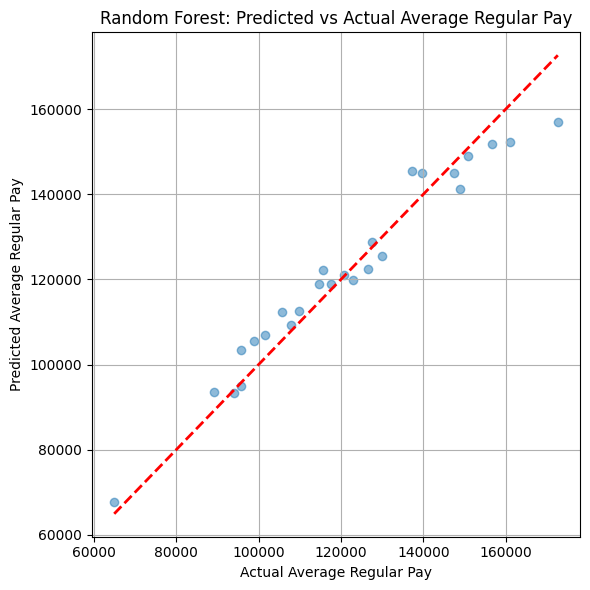

In [161]:
#plot of actual vs predicted
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel("Actual Average Regular Pay")
plt.ylabel("Predicted Average Regular Pay")
plt.title("Random Forest: Predicted vs Actual Average Regular Pay")
plt.grid(True)
plt.tight_layout()
plt.show()

**Linear Regression**

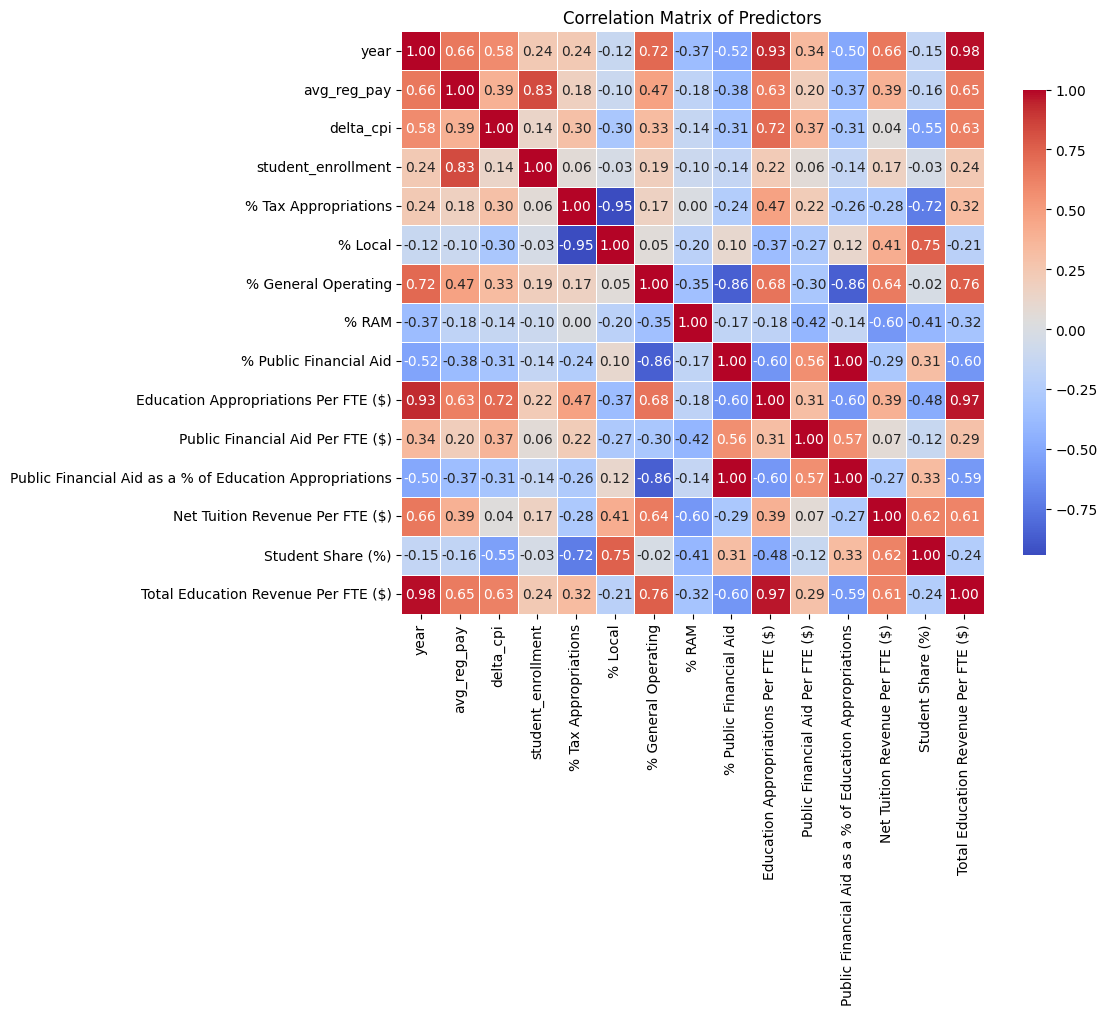

In [162]:
#correlation matrix and heatmap to check for multicollinearity

# 1. Subset numeric predictors only (excluding dummies if needed)
numeric_cols = uc_agg.select_dtypes(include=["float64", "int64"]).columns
corr_matrix = uc_agg[numeric_cols].corr()

# 2. Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True,
            cbar_kws={"shrink": 0.8}, linewidths=0.5)
plt.title("Correlation Matrix of Predictors")
plt.tight_layout()
plt.show()

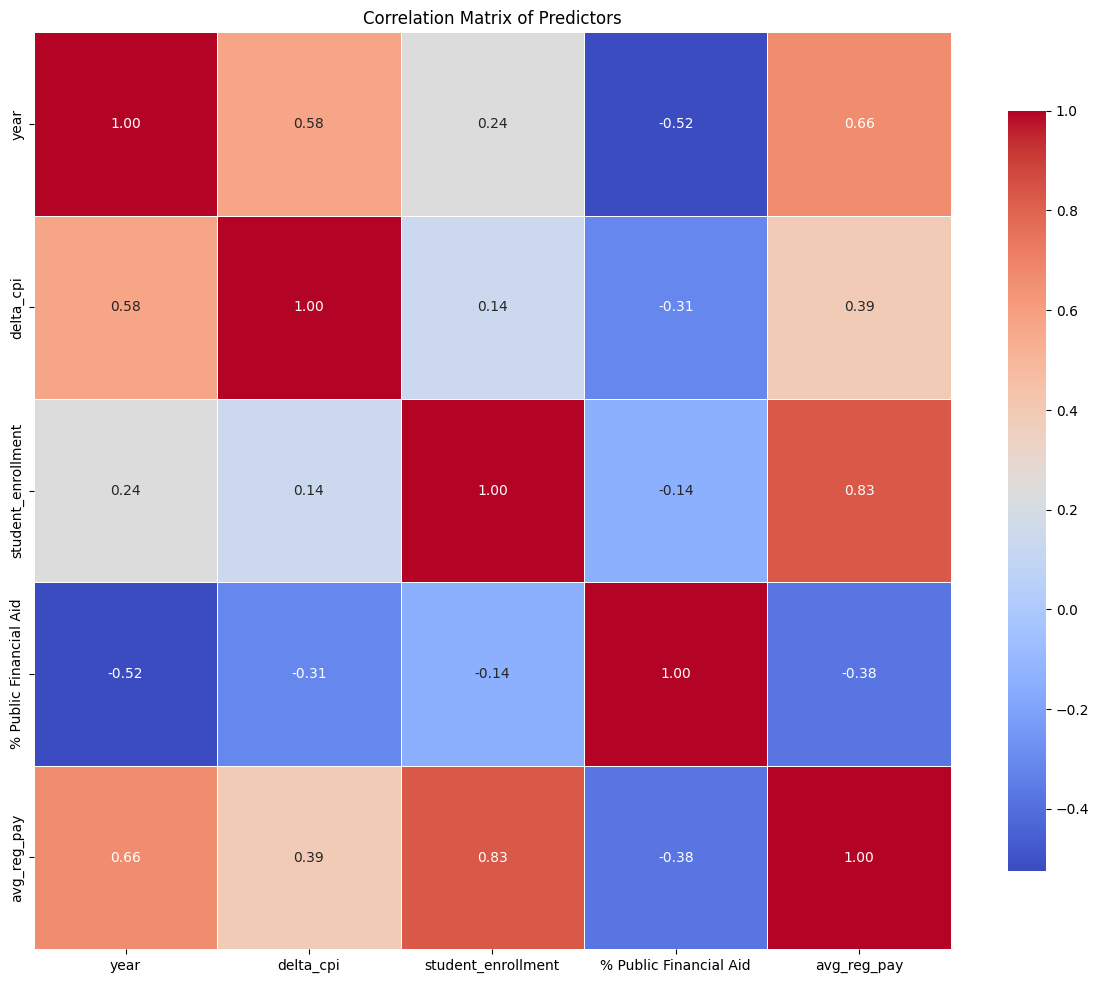

In [163]:
#correlation matrix/heatmap for features we have picked
numeric_cols = uc_agg[['year', 'delta_cpi', 'student_enrollment', '% Public Financial Aid',
                       'avg_reg_pay']]

corr_matrix = numeric_cols.corr()

# 2. Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True,
            cbar_kws={"shrink": 0.8}, linewidths=0.5)
plt.title("Correlation Matrix of Predictors")
plt.tight_layout()
plt.show()

In [164]:
#checking vif

# Keep only the relevant features + location
features = ['year', 'delta_cpi', 'student_enrollment', '% Public Financial Aid']

df_vif = uc_agg[features].copy()

X = sm.add_constant(df_vif)

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns[1:]
vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                   for i in range(1, X.shape[1])]

print(vif_data)

                  feature       VIF
0                    year  1.915690
1               delta_cpi  1.499409
2      student_enrollment  1.060839
3  % Public Financial Aid  1.379564


In [165]:
#linear regression model
base_features = [
    'year',
    'delta_cpi',
    'student_enrollment',
    '% Public Financial Aid',
]

# Step 2: One-hot encode 'location' (drop_first to avoid dummy trap)
X = uc_agg[base_features + ['location']]
X = pd.get_dummies(X, columns=['location'], drop_first=True)

# Step 3: Define target variable
y = uc_agg['avg_reg_pay']

# Step 4: Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 5: Fit linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 6: Predict
y_pred = model.predict(X_test)

# Step 7: Evaluate model
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

#adjusted R^2
adjusted_r2 = 1 - (1 - r2) * (len(y_test) - 1) / (len(y_test) - X_test.shape[1] - 1)

print("R² score:", r2)
print("Adjusted R² score:", adjusted_r2)
print("RMSE:", rmse)

# Step 8: View coefficients
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
}).sort_values(by="Coefficient", ascending=False)

print(coef_df)

R² score: 0.9721342792462945
Adjusted R² score: 0.9587587332845158
RMSE: 3922.0964059191792
                   Feature   Coefficient
6     location_Los Angeles  17114.084471
9       location_San Diego   3882.138159
0                     year   3853.643063
4           location_Davis   2075.122516
1                delta_cpi    303.661712
2       student_enrollment     -0.510674
3   % Public Financial Aid   -494.479405
5          location_Irvine  -3298.866819
10  location_Santa Barbara -13250.939019
8       location_Riverside -28683.219171
11     location_Santa Cruz -31025.567385
7          location_Merced -58743.471369


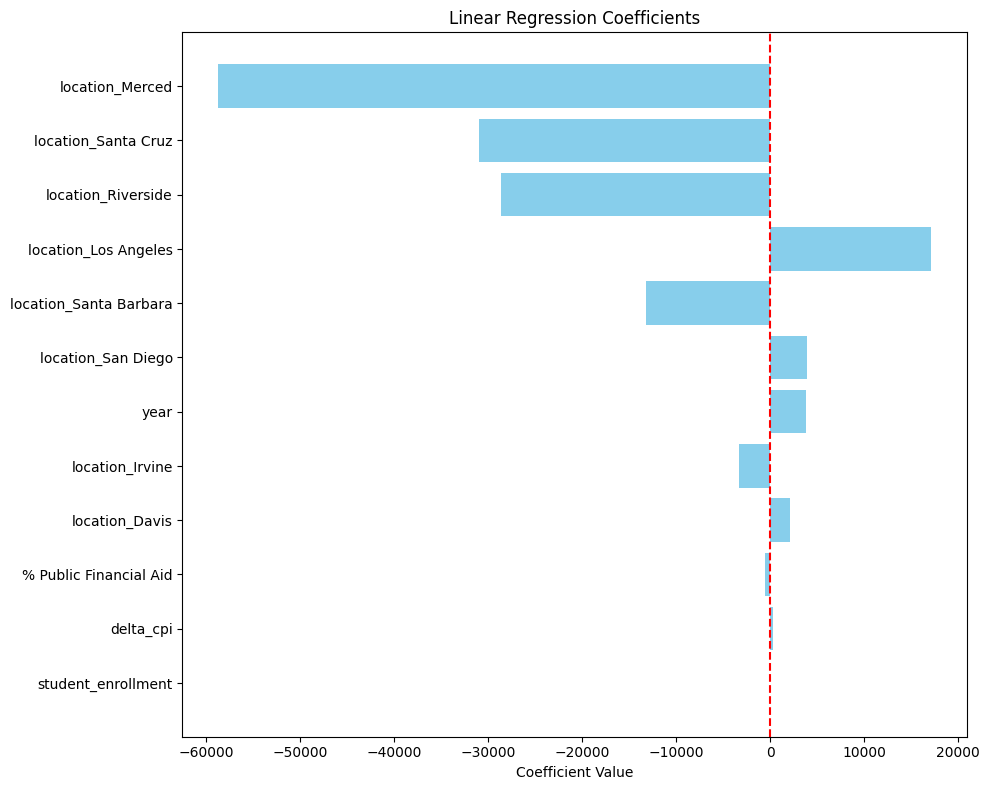

In [166]:
# Sort by absolute value of coefficient
coef_df['abs_coef'] = coef_df['Coefficient'].abs()
coef_df_sorted = coef_df.sort_values(by='abs_coef', ascending=True)

# Plot
plt.figure(figsize=(10, 8))
plt.barh(coef_df_sorted['Feature'], coef_df_sorted['Coefficient'], color='skyblue')
plt.axvline(x=0, color='red', linestyle='--')
plt.title("Linear Regression Coefficients")
plt.xlabel("Coefficient Value")
plt.tight_layout()
plt.show()

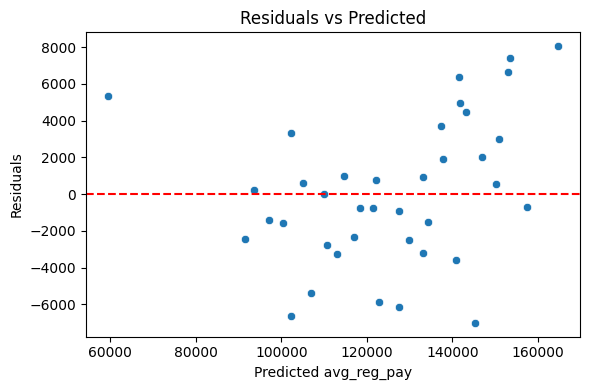

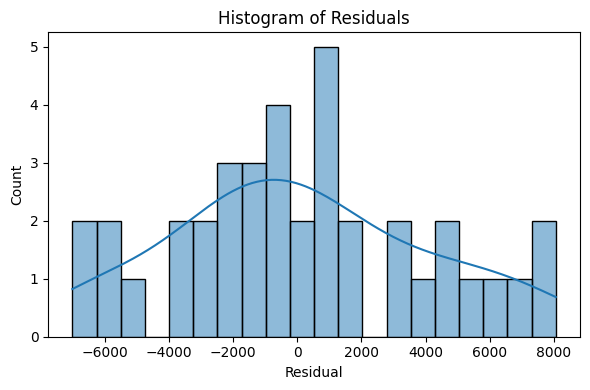

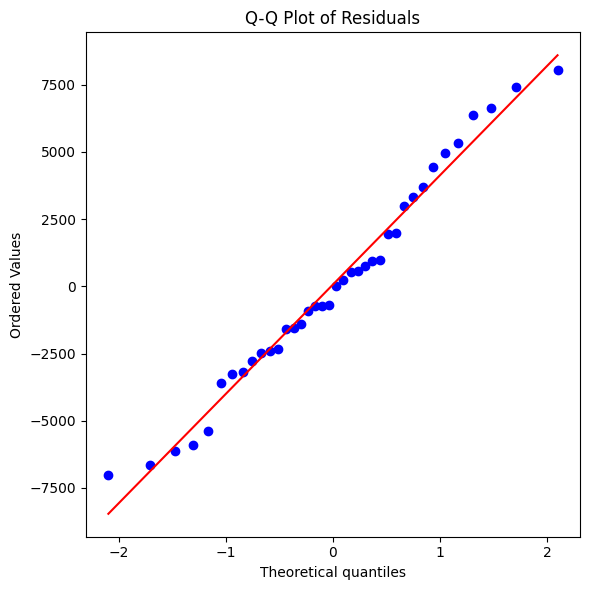

In [167]:
# 1. Compute residuals
residuals = y_test - y_pred

# 2. Plot residuals vs. predicted values (check for heteroscedasticity)
plt.figure(figsize=(6, 4))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted avg_reg_pay')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted')
plt.tight_layout()
plt.show()

# 3. Histogram of residuals (check for normality)
plt.figure(figsize=(6, 4))
sns.histplot(residuals, kde=True, bins=20)
plt.title('Histogram of Residuals')
plt.xlabel('Residual')
plt.tight_layout()
plt.show()

# 4. Q-Q Plot (check for normality)
plt.figure(figsize=(6, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot of Residuals')
plt.tight_layout()
plt.show()

In [168]:
#to get the pvalue, coefficient results, and std. error, etc for linear regression
base_features = [
    'year',
    'delta_cpi',
    'student_enrollment',
    '% Public Financial Aid',
]

# Step 2: One-hot encode 'location'
X = uc_agg[base_features + ['location']]
X = pd.get_dummies(X, columns=['location'], drop_first=True, dtype=int)

# Step 3: Define target variable
y = uc_agg['avg_reg_pay']

# Step 5: Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 6: Add constant term (intercept) for statsmodels
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

# Step 7: Fit OLS model using statsmodels
model_sm = sm.OLS(y_train, X_train_sm).fit()

# Step 8: Print the summary (this gives you the table format you want)
print(model_sm.summary())

# Step 9: Extract specific statistics into DataFrame (similar to your desired format)
results_df = pd.DataFrame({
    'Coefficients': model_sm.params.index,
    'Estimate': model_sm.params.values,
    'Std. Error': model_sm.bse.values,
    'P-Value': model_sm.pvalues.values
})

print("\nCustom Summary Table:")
print(results_df)

# Step 10: Predictions and evaluation (same as before)
y_pred = model_sm.predict(X_test_sm)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
adjusted_r2 = 1 - (1 - r2) * (len(y_test) - 1) / (len(y_test) - X_test_sm.shape[1] - 1)

print(f"\nModel Performance:")
print(f"R² score: {r2:.4f}")
print(f"Adjusted R² score: {adjusted_r2:.4f}")
print(f"RMSE: {rmse:.4f}")

                            OLS Regression Results                            
Dep. Variable:            avg_reg_pay   R-squared:                       0.987
Model:                            OLS   Adj. R-squared:                  0.985
Method:                 Least Squares   F-statistic:                     493.5
Date:                Wed, 11 Jun 2025   Prob (F-statistic):           3.74e-66
Time:                        00:43:22   Log-Likelihood:                -812.03
No. Observations:                  88   AIC:                             1650.
Df Residuals:                      75   BIC:                             1682.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                  -7.62

In [171]:
#cross validation
X = uc_agg[[
    'year', 'delta_cpi', 'student_enrollment', '% Public Financial Aid']]

X = pd.concat([X, pd.get_dummies(uc_agg['location'], drop_first=True)], axis=1)
y = uc_agg['avg_reg_pay']

# Convert to numpy arrays if needed for sklearn
X_np = X.to_numpy()
y_np = y.to_numpy()

# Initialize model and metrics
lrmodel = LinearRegression()
scores = []         # R² values
rmse_list = []      # RMSE values

# 10-fold CV
cv = KFold(n_splits=10, shuffle=True, random_state=42)
for train_index, test_index in cv.split(X_np):
    X_train, X_test = X_np[train_index], X_np[test_index]
    y_train, y_test = y_np[train_index], y_np[test_index]

    lrmodel.fit(X_train, y_train)
    y_pred = lrmodel.predict(X_test)

    scores.append(lrmodel.score(X_test, y_test))
    rmse_list.append(np.sqrt(mean_squared_error(y_test, y_pred)))

# Output CV results
print("Cross-validated R² mean:", np.mean(scores))
print("Cross-validated RMSE mean:", np.mean(rmse_list))

n = len(y_np)              # total number of samples
p = X_np.shape[1]          # number of predictors

mean_r2 = np.mean(scores)
adj_r2 = 1 - (1 - mean_r2) * ((n - 1) / (n - p - 1))

print("Adjusted Cross-validated R²:", adj_r2)

Cross-validated R² mean: 0.9729457729496728
Cross-validated RMSE mean: 3143.779195067114
Adjusted Cross-validated R²: 0.9700727576876911
